
Iniciando análise para: Sinal_1


Processando Sinal_1:   0%|          | 7/1000000 [00:00<4:22:24, 63.51it/s]

#--------------------------------------------------------------------------
#                         FastJet release 3.4.2
#                 M. Cacciari, G.P. Salam and G. Soyez                  
#     A software package for jet finding and analysis at colliders      
#                           http://fastjet.fr                           
#	                                                                      
# Please cite EPJC72(2012)1896 [arXiv:1111.6097] if you use this package
# for scientific work and optionally PLB641(2006)57 [hep-ph/0512210].   
#                                                                       
# FastJet is provided without warranty under the GNU GPL v2 or higher.  
# It uses T. Chan's closest pair algorithm, S. Fortune's Voronoi code,
# CGAL and 3rd party plugin jet algorithms. See COPYING file for details.
#--------------------------------------------------------------------------


Processando Sinal_1:  10%|█         | 100000/1000000 [25:39<3:50:57, 64.95it/s]



Iniciando análise para: Sinal_2


...


Iniciando análise para: Background_15


Processando Background_15: 100%|██████████| 1000000/1000000 [4:01:04<00:00, 69.14it/s] 



Iniciando análise para: Background_16


Processando Background_16: 100%|██████████| 1000000/1000000 [3:54:15<00:00, 71.15it/s] 



Cutflow final:

               Total                    Muon Pair                Muon Mass (100-150)      ≥2 Jets (pT>30, |η|<4.5) Dijet Mass (100-125)     ≥2 b-jets (nos 2 líderes)
---------------------------------------------------------------------------------------------------------------------------------------------------------------------
Sinal_1        100000                   64419                    61200                    54949                    8748                     8701                     
Sinal_2        100000                   64585                    61474                    55191                    8678                     8629                     
Sinal_3        100000                   64276                    61199                    54917                    8612                     8576                     
Sinal_4        100000                   64225                    61141                    54984                    8777                     8738         

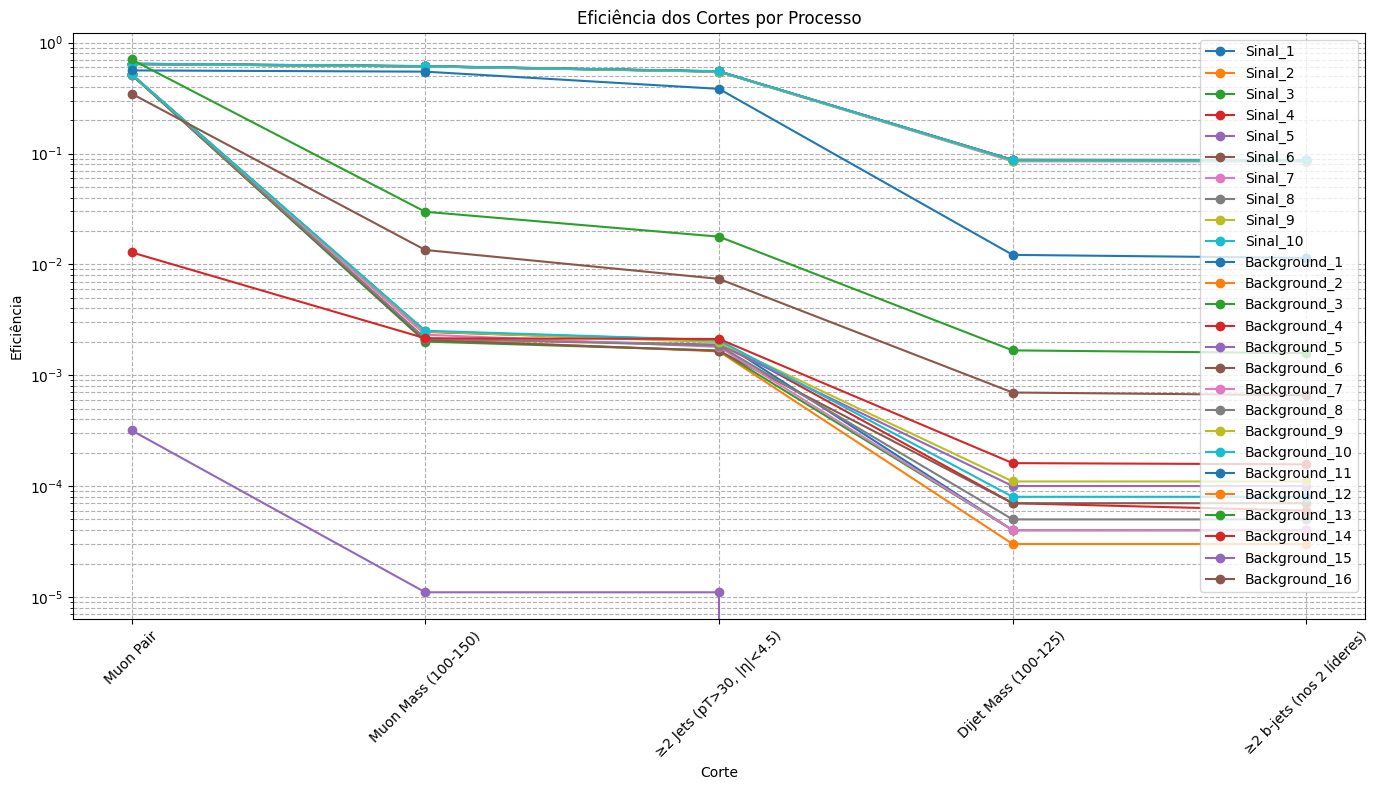

In [1]:
import pyhepmc as hep
import numpy as np
import pandas as pd
import fastjet as fj
import psutil
import os
import gc
import matplotlib.pyplot as plt
from tqdm import tqdm

# Configurações de memória e processamento
def print_memory_usage():
    process = psutil.Process(os.getpid())
    print(f"Uso de memória: {process.memory_info().rss / 1024 ** 2:.2f} MB")

max_events = 1000000
chunk_size = 1000000

# ========================
# Arquivos de entrada
# ========================
signal_files = [f'/home/lphelipe/Resultados/v3/pp_hh_{i}.hepmc' for i in range(1, 11)]
background_files = [
    '/home/lphelipe/Resultados/v3/pp_zz_1.hepmc',
    '/home/lphelipe/Resultados/v3/pp_zz_2.hepmc',
    '/home/lphelipe/Resultados/v3/pp_zz_3.hepmc',
    '/home/lphelipe/Resultados/v3/pp_zz_4.hepmc',
    '/home/lphelipe/Resultados/v3/pp_zz_5.hepmc',
    '/home/lphelipe/Resultados/v3/pp_zz_6.hepmc',
    '/home/lphelipe/Resultados/v3/pp_zz_7.hepmc',
    '/home/lphelipe/Resultados/v3/pp_zz_8.hepmc',
    '/home/lphelipe/Resultados/v3/pp_zz_9.hepmc',
    '/home/lphelipe/Resultados/v3/pp_zz_10.hepmc',
    '/home/lphelipe/Resultados/v3/pp_hjj_2mu.hepmc',
    '/home/lphelipe/Resultados/v3/pp_jj.hepmc',
    '/home/lphelipe/Resultados/v3/pp_jjmumu.hepmc',
    '/home/lphelipe/Resultados/v3/pp_tt.hepmc',
    '/home/lphelipe/Resultados/v3/pp_zjj_2b.hepmc',
    '/home/lphelipe/Resultados/v3/pp_zjj_2mu.hepmc'
]

# Criação do dicionário de arquivos
files = {}

# Adiciona todos os sinais
for i, fname in enumerate(signal_files, start=1):
    files[f"Sinal_{i}"] = fname

# Adiciona todos os backgrounds
for i, fname in enumerate(background_files, start=1):
    files[f"Background_{i}"] = fname

# Luminosidade do FCC-hh [fb^-1] (20000 fb^-1 = 20 ab^-1)
TARGET_LUMINOSITY = 20000.0  

# ========================
# Funções de física
# ========================
def is_b_tagged(jet, particles, cone_radius=0.4):
    secondary_vertex_displacement = []
    for p in particles:
        if p.production_vertex is not None:
            r_prod = np.sqrt(p.production_vertex.position.x**2 + p.production_vertex.position.y**2)
            secondary_vertex_displacement.append(r_prod)
    if len(secondary_vertex_displacement) > 0:
        mean_displacement = np.mean(secondary_vertex_displacement)
        return mean_displacement > 1.0, mean_displacement
    return False, 0.0

def invariant_mass(jet1, jet2):
    E_tot = jet1.e() + jet2.e()
    px_tot = jet1.px() + jet2.px()
    py_tot = jet1.py() + jet2.py()
    pz_tot = jet1.pz() + jet2.pz()
    return np.sqrt(E_tot**2 - (px_tot**2 + py_tot**2 + pz_tot**2))

def remove_muons(particles):
    return [p for p in particles if abs(p.pid) != 13]

def find_opposite_charge_muons(particles):
    muons = [p for p in particles if abs(p.pid) == 13 and p.momentum.pt() > 20.0 and abs(p.momentum.eta()) < 2.5]
    muons_sorted = sorted(muons, key=lambda m: m.momentum.pt(), reverse=True)
    pairs = []
    used_indices = set()
    for i in range(len(muons_sorted)):
        if i in used_indices:
            continue
        for j in range(i + 1, len(muons_sorted)):
            if j in used_indices:
                continue
            if muons_sorted[i].pid == -muons_sorted[j].pid:
                pairs.append((muons_sorted[i], muons_sorted[j]))
                used_indices.add(i)
                used_indices.add(j)
                break
    return pairs

def delta_r(jet1, jet2):
    dphi = jet1.phi() - jet2.phi()
    deta = jet1.eta() - jet2.eta()
    return np.sqrt(dphi**2 + deta**2)

def analyze_hepmc_file(filename, label, max_events=max_events):
    cutflow_steps = [
        "Total",
        "Muon Pair",
        "Muon Mass (100-150)",
        "≥2 Jets (pT>30, |η|<4.5)",
        "Dijet Mass (100-125)",
        "≥2 b-jets (nos 2 líderes)"
    ]
    cutflow = {step: 0 for step in cutflow_steps}
    results = []
    
    with hep.open(filename) as f:
        for i, event in enumerate(tqdm(f, desc=f"Processando {label}", total=max_events)):
            if i >= max_events:
                break
            cutflow["Total"] += 1
            
            particles = [p for p in event.particles if p.status == 1 and p.momentum.pt() > 2.0]
            muon_pairs = find_opposite_charge_muons(particles)
            if not muon_pairs:
                continue
            cutflow["Muon Pair"] += 1
            
            muon1 = fj.PseudoJet(muon_pairs[0][0].momentum.x, muon_pairs[0][0].momentum.y, 
                                muon_pairs[0][0].momentum.z, muon_pairs[0][0].momentum.e)
            muon2 = fj.PseudoJet(muon_pairs[0][1].momentum.x, muon_pairs[0][1].momentum.y, 
                                muon_pairs[0][1].momentum.z, muon_pairs[0][1].momentum.e)
            
            inv_mass = invariant_mass(muon1, muon2)
            if not (100 < inv_mass < 150):
                continue
            cutflow["Muon Mass (100-150)"] += 1
            
            particles_no_muons = remove_muons(particles)
            fj_particles = [fj.PseudoJet(p.momentum.x, p.momentum.y, p.momentum.z, p.momentum.e) 
                          for p in particles_no_muons]
            
            jet_def = fj.JetDefinition(fj.antikt_algorithm, 0.4)
            cluster_seq = fj.ClusterSequence(fj_particles, jet_def)
            jets = [j for j in cluster_seq.inclusive_jets(30.0) if abs(j.eta()) < 4.5]
            
            if len(jets) < 2:
                continue
            cutflow["≥2 Jets (pT>30, |η|<4.5)"] += 1
            
            jets_sorted = sorted(jets, key=lambda j: j.pt(), reverse=True)
            jet1, jet2 = jets_sorted[0], jets_sorted[1]
            
            dijet_mass = invariant_mass(jet1, jet2)
            if not (100 <= dijet_mass <= 125):
                continue
            cutflow["Dijet Mass (100-125)"] += 1
            
            is_b_tagged1, b_tag_distance1 = is_b_tagged(jet1, particles_no_muons)
            is_b_tagged2, b_tag_distance2 = is_b_tagged(jet2, particles_no_muons)
            
            if not (is_b_tagged1 and is_b_tagged2):
                continue
            cutflow["≥2 b-jets (nos 2 líderes)"] += 1
            
            results.append({
                'muon_mass': inv_mass,
                'muon1_pt': muon1.pt(),
                'muon2_pt': muon2.pt(),
                'dijet_mass': dijet_mass,
                'jet1_pt': jet1.pt(),
                'jet2_pt': jet2.pt(),
                'jet1_is_b_tagged': is_b_tagged1,
                'jet2_is_b_tagged': is_b_tagged2,
                'b_tag_distance1': b_tag_distance1,
                'b_tag_distance2': b_tag_distance2,
                'weight': event.weights[-1] if event.weights else 1.0,
                'label': label
            })
            
            if i % chunk_size == 0:
                gc.collect()
                print_memory_usage()
    
    return pd.DataFrame(results), cutflow

# ========================
# Processamento principal
# ========================
all_results = []
cutflows = {}

for label, filename in files.items():
    print(f"\nIniciando análise para: {label}")
    df, cutflow = analyze_hepmc_file(filename, label)
    all_results.append(df)
    cutflows[label] = cutflow

# ========================
# Cutflow final
# ========================
print("\nCutflow final:\n")
first_cutflow = next(iter(cutflows.values()))
cutflow_steps = list(first_cutflow.keys())
header = f"{'':<15}" + "".join([f"{step:<25}" for step in cutflow_steps])
print(header)
print("-" * len(header))
for label, cutflow in cutflows.items():
    row = f"{label:<15}"
    for step in cutflow_steps:
        row += f"{cutflow.get(step, 'N/A'):<25}"
    print(row)

# ========================
# Salva resultados
# ========================
final_df = pd.concat(all_results)
output_dir = "cutflow"
os.makedirs(output_dir, exist_ok=True)

signal_df = final_df[final_df['label'].str.contains("Sinal")]
background_df = final_df[~final_df['label'].str.contains("Sinal")]

signal_df.to_csv(os.path.join(output_dir, "signal_cutflow_v4.csv"), index=False)
background_df.to_csv(os.path.join(output_dir, "background_cutflow_v4.csv"), index=False)
final_df.to_csv(os.path.join(output_dir, "all_events_cutflow_v4.csv"), index=False)

# ========================
# Plot do cutflow
# ========================
plt.figure(figsize=(14, 8))
for label, cutflow in cutflows.items():
    steps = list(cutflow.keys())[1:]
    values = [cutflow[step]/cutflow['Total'] for step in steps]
    plt.plot(steps, values, 'o-', label=label)

plt.title("Eficiência dos Cortes por Processo")
plt.xlabel("Corte")
plt.ylabel("Eficiência")
plt.xticks(rotation=45)
plt.yscale('log')
plt.legend()
plt.grid(True, which='both', linestyle='--')
plt.tight_layout()
plt.savefig("cutflow_efficiency_v5.png")
plt.show()



Iniciando análise para: Sinal_1


Processando Sinal_1:   0%|          | 15/1000000 [00:00<4:01:26, 69.03it/s]

#--------------------------------------------------------------------------
#                         FastJet release 3.4.2
#                 M. Cacciari, G.P. Salam and G. Soyez                  
#     A software package for jet finding and analysis at colliders      
#                           http://fastjet.fr                           
#	                                                                      
# Please cite EPJC72(2012)1896 [arXiv:1111.6097] if you use this package
# for scientific work and optionally PLB641(2006)57 [hep-ph/0512210].   
#                                                                       
# FastJet is provided without warranty under the GNU GPL v2 or higher.  
# It uses T. Chan's closest pair algorithm, S. Fortune's Voronoi code,
# CGAL and 3rd party plugin jet algorithms. See COPYING file for details.
#--------------------------------------------------------------------------


Processando Sinal_1:  10%|█         | 100000/1000000 [26:56<4:02:28, 61.86it/s]



Iniciando análise para: Sinal_2


...


Iniciando análise para: Background_15


Processando Background_15: 100%|██████████| 1000000/1000000 [4:19:12<00:00, 64.30it/s]  



Iniciando análise para: Background_16


Processando Background_16: 100%|██████████| 1000000/1000000 [3:59:09<00:00, 69.69it/s]  



Cutflow final:

               Total                    Muon Pair                Muon Mass (123-126)      ≥2 Jets (pT>30, |η|<4.5) Dijet Mass (100-125)     ≥2 b-jets (nos 2 líderes)
---------------------------------------------------------------------------------------------------------------------------------------------------------------------
Sinal_1        100000                   64419                    53181                    47647                    7657                     7615                     
Sinal_2        100000                   64585                    53636                    48097                    7654                     7612                     
Sinal_3        100000                   64276                    53274                    47724                    7532                     7502                     
Sinal_4        100000                   64225                    53182                    47772                    7687                     7655         

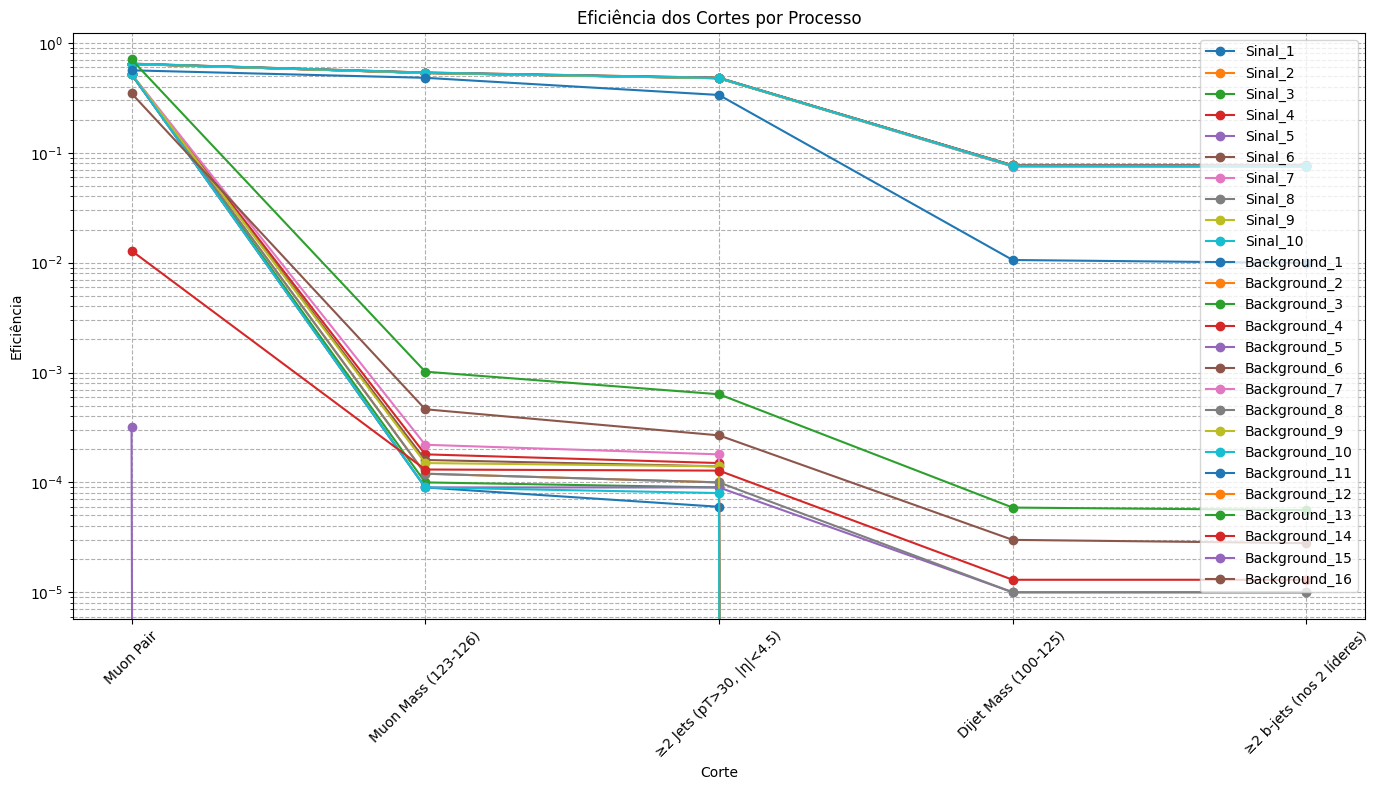

In [1]:
import pyhepmc as hep
import numpy as np
import pandas as pd
import fastjet as fj
import psutil
import os
import gc
import matplotlib.pyplot as plt
from tqdm import tqdm

# Configurações de memória e processamento
def print_memory_usage():
    process = psutil.Process(os.getpid())
    print(f"Uso de memória: {process.memory_info().rss / 1024 ** 2:.2f} MB")

max_events = 1000000
chunk_size = 1000000

# ========================
# Arquivos de entrada
# ========================
signal_files = [f'/home/lphelipe/Resultados/v3/pp_hh_{i}.hepmc' for i in range(1, 11)]
background_files = [
    '/home/lphelipe/Resultados/v3/pp_zz_1.hepmc',
    '/home/lphelipe/Resultados/v3/pp_zz_2.hepmc',
    '/home/lphelipe/Resultados/v3/pp_zz_3.hepmc',
    '/home/lphelipe/Resultados/v3/pp_zz_4.hepmc',
    '/home/lphelipe/Resultados/v3/pp_zz_5.hepmc',
    '/home/lphelipe/Resultados/v3/pp_zz_6.hepmc',
    '/home/lphelipe/Resultados/v3/pp_zz_7.hepmc',
    '/home/lphelipe/Resultados/v3/pp_zz_8.hepmc',
    '/home/lphelipe/Resultados/v3/pp_zz_9.hepmc',
    '/home/lphelipe/Resultados/v3/pp_zz_10.hepmc',
    '/home/lphelipe/Resultados/v3/pp_hjj_2mu.hepmc',
    '/home/lphelipe/Resultados/v3/pp_jj.hepmc',
    '/home/lphelipe/Resultados/v3/pp_jjmumu.hepmc',
    '/home/lphelipe/Resultados/v3/pp_tt.hepmc',
    '/home/lphelipe/Resultados/v3/pp_zjj_2b.hepmc',
    '/home/lphelipe/Resultados/v3/pp_zjj_2mu.hepmc'
]

# Criação do dicionário de arquivos
files = {}

# Adiciona todos os sinais
for i, fname in enumerate(signal_files, start=1):
    files[f"Sinal_{i}"] = fname

# Adiciona todos os backgrounds
for i, fname in enumerate(background_files, start=1):
    files[f"Background_{i}"] = fname

# Luminosidade do FCC-hh [fb^-1] (20000 fb^-1 = 20 ab^-1)
TARGET_LUMINOSITY = 20000.0  

# ========================
# Funções de física
# ========================
def is_b_tagged(jet, particles, cone_radius=0.4):
    secondary_vertex_displacement = []
    for p in particles:
        if p.production_vertex is not None:
            r_prod = np.sqrt(p.production_vertex.position.x**2 + p.production_vertex.position.y**2)
            secondary_vertex_displacement.append(r_prod)
    if len(secondary_vertex_displacement) > 0:
        mean_displacement = np.mean(secondary_vertex_displacement)
        return mean_displacement > 1.0, mean_displacement
    return False, 0.0

def invariant_mass(jet1, jet2):
    E_tot = jet1.e() + jet2.e()
    px_tot = jet1.px() + jet2.px()
    py_tot = jet1.py() + jet2.py()
    pz_tot = jet1.pz() + jet2.pz()
    return np.sqrt(E_tot**2 - (px_tot**2 + py_tot**2 + pz_tot**2))

def remove_muons(particles):
    return [p for p in particles if abs(p.pid) != 13]

def find_opposite_charge_muons(particles):
    muons = [p for p in particles if abs(p.pid) == 13 and p.momentum.pt() > 20.0 and abs(p.momentum.eta()) < 2.5]
    muons_sorted = sorted(muons, key=lambda m: m.momentum.pt(), reverse=True)
    pairs = []
    used_indices = set()
    for i in range(len(muons_sorted)):
        if i in used_indices:
            continue
        for j in range(i + 1, len(muons_sorted)):
            if j in used_indices:
                continue
            if muons_sorted[i].pid == -muons_sorted[j].pid:
                pairs.append((muons_sorted[i], muons_sorted[j]))
                used_indices.add(i)
                used_indices.add(j)
                break
    return pairs

def delta_r(jet1, jet2):
    dphi = jet1.phi() - jet2.phi()
    deta = jet1.eta() - jet2.eta()
    return np.sqrt(dphi**2 + deta**2)

def analyze_hepmc_file(filename, label, max_events=max_events):
    cutflow_steps = [
        "Total",
        "Muon Pair",
        "Muon Mass (123-126)",
        "≥2 Jets (pT>30, |η|<4.5)",
        "Dijet Mass (100-125)",
        "≥2 b-jets (nos 2 líderes)"
    ]
    cutflow = {step: 0 for step in cutflow_steps}
    results = []
    
    with hep.open(filename) as f:
        for i, event in enumerate(tqdm(f, desc=f"Processando {label}", total=max_events)):
            if i >= max_events:
                break
            cutflow["Total"] += 1
            
            particles = [p for p in event.particles if p.status == 1 and p.momentum.pt() > 2.0]
            muon_pairs = find_opposite_charge_muons(particles)
            if not muon_pairs:
                continue
            cutflow["Muon Pair"] += 1
            
            muon1 = fj.PseudoJet(muon_pairs[0][0].momentum.x, muon_pairs[0][0].momentum.y, 
                                muon_pairs[0][0].momentum.z, muon_pairs[0][0].momentum.e)
            muon2 = fj.PseudoJet(muon_pairs[0][1].momentum.x, muon_pairs[0][1].momentum.y, 
                                muon_pairs[0][1].momentum.z, muon_pairs[0][1].momentum.e)
            
            inv_mass = invariant_mass(muon1, muon2)
            if not (123 < inv_mass < 126):
                continue
            cutflow["Muon Mass (123-126)"] += 1
            
            particles_no_muons = remove_muons(particles)
            fj_particles = [fj.PseudoJet(p.momentum.x, p.momentum.y, p.momentum.z, p.momentum.e) 
                          for p in particles_no_muons]
            
            jet_def = fj.JetDefinition(fj.antikt_algorithm, 0.4)
            cluster_seq = fj.ClusterSequence(fj_particles, jet_def)
            jets = [j for j in cluster_seq.inclusive_jets(30.0) if abs(j.eta()) < 4.5]
            
            if len(jets) < 2:
                continue
            cutflow["≥2 Jets (pT>30, |η|<4.5)"] += 1
            
            jets_sorted = sorted(jets, key=lambda j: j.pt(), reverse=True)
            jet1, jet2 = jets_sorted[0], jets_sorted[1]
            
            dijet_mass = invariant_mass(jet1, jet2)
            if not (100 <= dijet_mass <= 125):
                continue
            cutflow["Dijet Mass (100-125)"] += 1
            
            is_b_tagged1, b_tag_distance1 = is_b_tagged(jet1, particles_no_muons)
            is_b_tagged2, b_tag_distance2 = is_b_tagged(jet2, particles_no_muons)
            
            if not (is_b_tagged1 and is_b_tagged2):
                continue
            cutflow["≥2 b-jets (nos 2 líderes)"] += 1
            
            results.append({
                'muon_mass': inv_mass,
                'muon1_pt': muon1.pt(),
                'muon2_pt': muon2.pt(),
                'dijet_mass': dijet_mass,
                'jet1_pt': jet1.pt(),
                'jet2_pt': jet2.pt(),
                'jet1_is_b_tagged': is_b_tagged1,
                'jet2_is_b_tagged': is_b_tagged2,
                'b_tag_distance1': b_tag_distance1,
                'b_tag_distance2': b_tag_distance2,
                'weight': event.weights[-1] if event.weights else 1.0,
                'label': label
            })
            
            if i % chunk_size == 0:
                gc.collect()
                print_memory_usage()
    
    return pd.DataFrame(results), cutflow

# ========================
# Processamento principal
# ========================
all_results = []
cutflows = {}

for label, filename in files.items():
    print(f"\nIniciando análise para: {label}")
    df, cutflow = analyze_hepmc_file(filename, label)
    all_results.append(df)
    cutflows[label] = cutflow

# ========================
# Cutflow final
# ========================
print("\nCutflow final:\n")
first_cutflow = next(iter(cutflows.values()))
cutflow_steps = list(first_cutflow.keys())
header = f"{'':<15}" + "".join([f"{step:<25}" for step in cutflow_steps])
print(header)
print("-" * len(header))
for label, cutflow in cutflows.items():
    row = f"{label:<15}"
    for step in cutflow_steps:
        row += f"{cutflow.get(step, 'N/A'):<25}"
    print(row)

# ========================
# Salva resultados
# ========================
final_df = pd.concat(all_results)
output_dir = "cutflow"
os.makedirs(output_dir, exist_ok=True)

signal_df = final_df[final_df['label'].str.contains("Sinal")]
background_df = final_df[~final_df['label'].str.contains("Sinal")]

signal_df.to_csv(os.path.join(output_dir, "signal_cutflow_v6.csv"), index=False)
background_df.to_csv(os.path.join(output_dir, "background_cutflow_v6.csv"), index=False)
final_df.to_csv(os.path.join(output_dir, "all_events_cutflow_v6.csv"), index=False)

# ========================
# Plot do cutflow
# ========================
plt.figure(figsize=(14, 8))
for label, cutflow in cutflows.items():
    steps = list(cutflow.keys())[1:]
    values = [cutflow[step]/cutflow['Total'] for step in steps]
    plt.plot(steps, values, 'o-', label=label)

plt.title("Eficiência dos Cortes por Processo")
plt.xlabel("Corte")
plt.ylabel("Eficiência")
plt.xticks(rotation=45)
plt.yscale('log')
plt.legend()
plt.grid(True, which='both', linestyle='--')
plt.tight_layout()
plt.savefig("cutflow_efficiency_v6.png")
plt.show()
